In [ ]:
!pip install pandas seaborn scikit-learn

# Домашнее задание 4

1. Преобразовать датасет (процессинг категориальных признаков, копия данных в df_not_processed, scale датасета)
2. Сделать k-means кластеризацию (записать cluster в df_not_processed, вывести статистику, графики. попробовать объяснить принцип кластеризации), оценить метриками, вывести результат
3. Подобрать оптимальное число кластеров с помощью "метод локтя", вывести статистику, графики, метрики, объяснить результат
4. Сделать DBSSCAN кластеризацию, подобрать оптимальные параметры, посчитать метрики, вывести статистику, объяснить результат
5. Ответить на вопрос - какой из методов кластеризации больше подходит для вашего датасета

# Преобразование датасета

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

# Загружаем данные
df = pd.read_csv('Titanic-Dataset.csv')

# Создаем копию ДО обработки
df_not_processed = df.copy()

print("Исходные данные:")
print(f"Размер: {df.shape}")
print("\nПропуски:")
print(df.isnull().sum())

Исходные данные:
Размер: (891, 12)

Пропуски:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Обработка пропусков
# Age - заполняем медианным значением
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

# Embarked - заполняем модой
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

# Cabin - удаляем (слишком много пропусков)
df = df.drop('Cabin', axis=1)

In [ ]:
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Survived']
df = df.drop(columns_to_drop, axis=1, errors='ignore')

In [ ]:
# Категориальные признаки
categorical_for_clustering = ['Pclass', 'Sex', 'Embarked']
for col in categorical_for_clustering:
    df[col] = df[col].astype('category')

# One-Hot Encoding
category_columns = df.select_dtypes(include=['category']).columns
df = pd.get_dummies(df, columns=category_columns, drop_first=True)

# НОРМАЛИЗАЦИЯ С StandardScaler
numeric_features = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

# X для кластеризации
X = df
print(f"X для кластеризации: {X.shape}")
print(f"Использован StandardScaler (более устойчив к выбросам)")

X для кластеризации: (891, 9)
Использован StandardScaler (более устойчив к выбросам)


In [ ]:
# Посмотрим на данные после StandardScaler
print("Данные после StandardScaler:")
print(df[numeric_features].describe())

# Проверим, что mean ≈ 0 и std ≈ 1
print("\nПроверка StandardScaler:")
for feature in numeric_features:
    mean_val = df[feature].mean()
    std_val = df[feature].std()
    print(f"{feature}: mean={mean_val:.4f}, std={std_val:.4f}")

Данные после StandardScaler:
                Age         SibSp         Parch          Fare
count  8.910000e+02  8.910000e+02  8.910000e+02  8.910000e+02
mean   2.272780e-16  4.386066e-17  5.382900e-17  3.987333e-18
std    1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00
min   -2.224156e+00 -4.745452e-01 -4.736736e-01 -6.484217e-01
25%   -5.657365e-01 -4.745452e-01 -4.736736e-01 -4.891482e-01
50%   -1.046374e-01 -4.745452e-01 -4.736736e-01 -3.573909e-01
75%    4.333115e-01  4.327934e-01 -4.736736e-01 -2.424635e-02
max    3.891554e+00  6.784163e+00  6.974147e+00  9.667167e+00

Проверка StandardScaler:
Age: mean=0.0000, std=1.0006
SibSp: mean=0.0000, std=1.0006
Parch: mean=0.0000, std=1.0006
Fare: mean=0.0000, std=1.0006


# K-means кластеризация

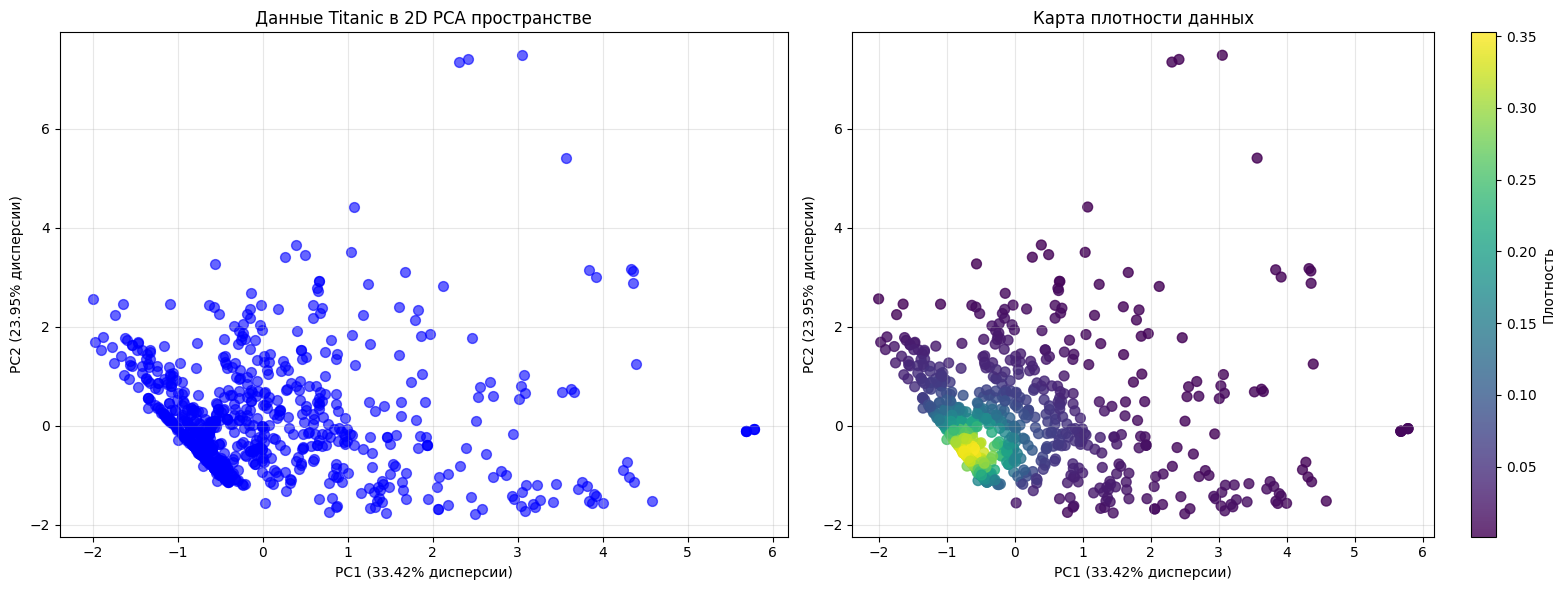

Объясненная дисперсия: 57.37%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.stats import gaussian_kde

# Снижаем размерность до 2D для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Первый график - обычная scatter plot
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=50, c='blue')
ax1.set_title('Данные Titanic в 2D PCA пространстве')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} дисперсии)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} дисперсии)')
ax1.grid(True, alpha=0.3)

# Второй график - карта плотности
xy = np.vstack([X_pca[:, 0], X_pca[:, 1]])
z = gaussian_kde(xy)(xy)
sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=z, s=50, alpha=0.8, cmap='viridis')
ax2.set_title('Карта плотности данных')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} дисперсии)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} дисперсии)')
ax2.grid(True, alpha=0.3)

# Добавляем colorbar для карты плотности
cbar = plt.colorbar(sc2, ax=ax2)
cbar.set_label('Плотность')

plt.tight_layout()
plt.show()

print(f"Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

In [ ]:
# 2 Создание модели K-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

# Записываем cluster в df_not_processed
df_not_processed['cluster'] = clusters

print(f"Найдено кластеров: {len(np.unique(clusters))}")
print(f"Размер кластеров:")
cluster_sizes = pd.Series(clusters).value_counts().sort_index()
for cluster, size in cluster_sizes.items():
    print(f"  Кластер {cluster}: {size} пассажиров ({size/len(clusters)*100:.1f}%)")

Найдено кластеров: 3
Размер кластеров:
  Кластер 0: 589 пассажиров (66.1%)
  Кластер 1: 179 пассажиров (20.1%)
  Кластер 2: 123 пассажиров (13.8%)


/tmp/ipython-input-3284029029.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('viridis', 3), alpha=0.7, s=50)


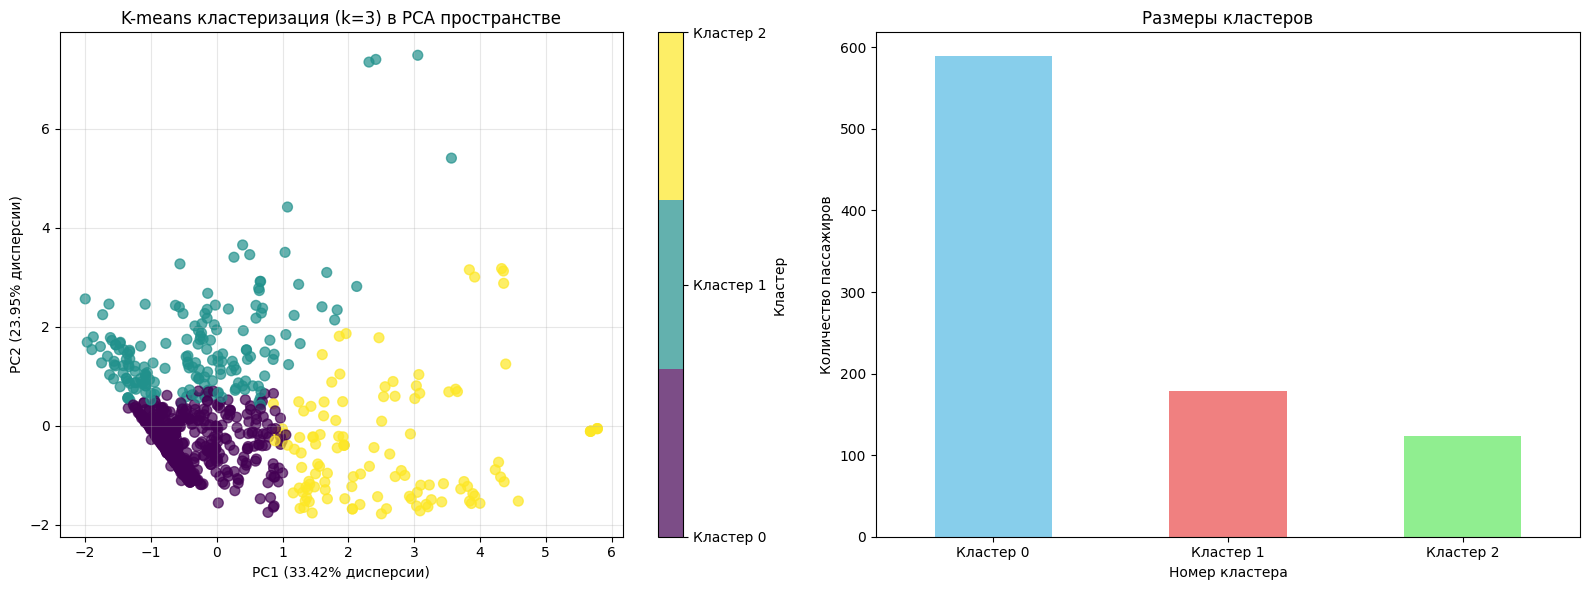

In [ ]:
# 3 Визуализация результатов кластеризации
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Кластеры в PCA пространстве
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters,
                      cmap=plt.cm.get_cmap('viridis', 3), alpha=0.7, s=50)
ax1.set_title('K-means кластеризация (k=3) в PCA пространстве')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} дисперсии)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} дисперсии)')
ax1.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter1, ax=ax1, label='Кластер')
cbar.set_ticks([0, 1, 2])
cbar.set_ticklabels(['Кластер 0', 'Кластер 1', 'Кластер 2'])

# График 2: Размеры кластеров
cluster_sizes.plot(kind='bar', ax=ax2, color=['skyblue', 'lightcoral', 'lightgreen'])
ax2.set_title('Размеры кластеров')
ax2.set_xlabel('Номер кластера')
ax2.set_ylabel('Количество пассажиров')
ax2.set_xticklabels(['Кластер 0', 'Кластер 1', 'Кластер 2'], rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
# 4. Статистика по кластерам

# Основная статистика
cluster_stats = df_not_processed.groupby('cluster').agg({
    'Age': ['mean', 'std'],
    'Fare': ['mean', 'std'],
    'Pclass': lambda x: x.mode()[0],
    'Sex': lambda x: (x == 'male').mean(),  # Доля мужчин
    'Embarked': lambda x: x.mode()[0],
    'SibSp': 'mean',
    'Parch': 'mean'
}).round(2)

print(cluster_stats)

# Детальная статистика
for cluster in sorted(df_not_processed['cluster'].unique()):
    cluster_data = df_not_processed[df_not_processed['cluster'] == cluster]
    print(f"\n--- Кластер {cluster} ({len(cluster_data)} пассажиров) ---")
    print(f"  Средний возраст: {cluster_data['Age'].mean():.1f} лет")
    print(f"  Средняя цена билета: {cluster_data['Fare'].mean():.1f}")
    print(f"  Мужчины: {(cluster_data['Sex'] == 'male').sum()} ({(cluster_data['Sex'] == 'male').mean()*100:.1f}%)")
    print(f"  Женщины: {(cluster_data['Sex'] == 'female').sum()} ({(cluster_data['Sex'] == 'female').mean()*100:.1f}%)")
    print(f"  Распределение по классам:")
    for pclass in sorted(cluster_data['Pclass'].unique()):
        count = (cluster_data['Pclass'] == pclass).sum()
        print(f"    {pclass} класс: {count} пассажиров")

           Age          Fare          Pclass      Sex Embarked SibSp Parch
          mean    std   mean    std <lambda> <lambda> <lambda>  mean  mean
cluster                                                                   
0        26.61   8.10  16.05  16.07        3     0.72        S  0.23  0.08
1        47.05  11.66  75.05  81.79        1     0.55        S  0.40  0.28
2        14.56  13.26  47.21  53.19        3     0.42        S  2.11  1.94

--- Кластер 0 (589 пассажиров) ---
  Средний возраст: 26.6 лет
  Средняя цена билета: 16.0
  Мужчины: 427 (72.5%)
  Женщины: 162 (27.5%)
  Распределение по классам:
    1 класс: 69 пассажиров
    2 класс: 121 пассажиров
    3 класс: 399 пассажиров

--- Кластер 1 (179 пассажиров) ---
  Средний возраст: 47.0 лет
  Средняя цена билета: 75.1
  Мужчины: 98 (54.7%)
  Женщины: 81 (45.3%)
  Распределение по классам:
    1 класс: 130 пассажиров
    2 класс: 35 пассажиров
    3 класс: 14 пассажиров

--- Кластер 2 (123 пассажиров) ---
  Средний возраст: 

**Предполагаемая интерпретация кластеров:**

Первый кластер:  Вероятно мужчины эконом-класса, средний возраст 26 лет, средняя цена билета 16, преобладающий класс: 3

Второй кластер: Вероятно богатые пассажиры 1 класса, средний возраст 47 лет,средняя цена билета 75

Третий кластер: Смешанная группа, среднего возраста 14 лет, средняя цена билета 47 с преобладающим классом 3

In [ ]:
# 5. Метрики

# Вычисляем метрики
silhouette = silhouette_score(X, clusters)
davies_bouldin = davies_bouldin_score(X, clusters)
calinski_harabasz = calinski_harabasz_score(X, clusters)

print(f"Silhouette Score: {silhouette:.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.3f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.3f}")

# Интерпретация метрик
print()
print(f"Silhouette Score: {silhouette:.3f} - {'Хорошо' if silhouette > 0.5 else 'Удовлетворительно' if silhouette > 0.25 else 'Плохо'}")
print(f"Davies-Bouldin: {davies_bouldin:.3f} - {'Хорошо' if davies_bouldin < 1.0 else 'Удовлетворительно, кластеры средне разделены' if davies_bouldin < 2.0 else 'Плохо'}")
print(f"Calinski-Harabasz: {calinski_harabasz:.3f} - {'Хорошо' if calinski_harabasz > 300 else 'Удовлетворительно' if calinski_harabasz > 200 else 'Плохо'}")

Silhouette Score: 0.312
Davies-Bouldin Index: 1.456
Calinski-Harabasz Index: 245.505

Silhouette Score: 0.312 - Удовлетворительно
Davies-Bouldin: 1.456 - Удовлетворительно, кластеры средне разделены
Calinski-Harabasz: 245.505 - Удовлетворительно


# Метод локтя

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Тестируем разные k (2-10) чтобы посмотреть как меняются метрики
k_range = range(1, 11)
inertias = []
silhouette_scores = []

#  Для каждого k создаем модель K-means, кластеризуем данные и сохраняем inertia
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X)

    inertias.append(kmeans.inertia_)

    # Silhouette можно считать только для k >= 2
    if k >= 2:
        silhouette_scores.append(silhouette_score(X, clusters))
    else:
        silhouette_scores.append(0)  # Для k=1 silhouette не определен

    print(f"k={k}: inertia = {kmeans.inertia_:.1f}", end="")
    if k >= 2:
        print(f", silhouette = {silhouette_scores[-1]:.3f}")
    else:
        print()

k=1: inertia = 4381.7
k=2: inertia = 3347.0, silhouette = 0.436
k=3: inertia = 2821.6, silhouette = 0.312
k=4: inertia = 2412.7, silhouette = 0.280
k=5: inertia = 2044.6, silhouette = 0.298
k=6: inertia = 1837.3, silhouette = 0.261
k=7: inertia = 1678.7, silhouette = 0.265
k=8: inertia = 1539.6, silhouette = 0.265
k=9: inertia = 1436.2, silhouette = 0.271
k=10: inertia = 1359.0, silhouette = 0.281


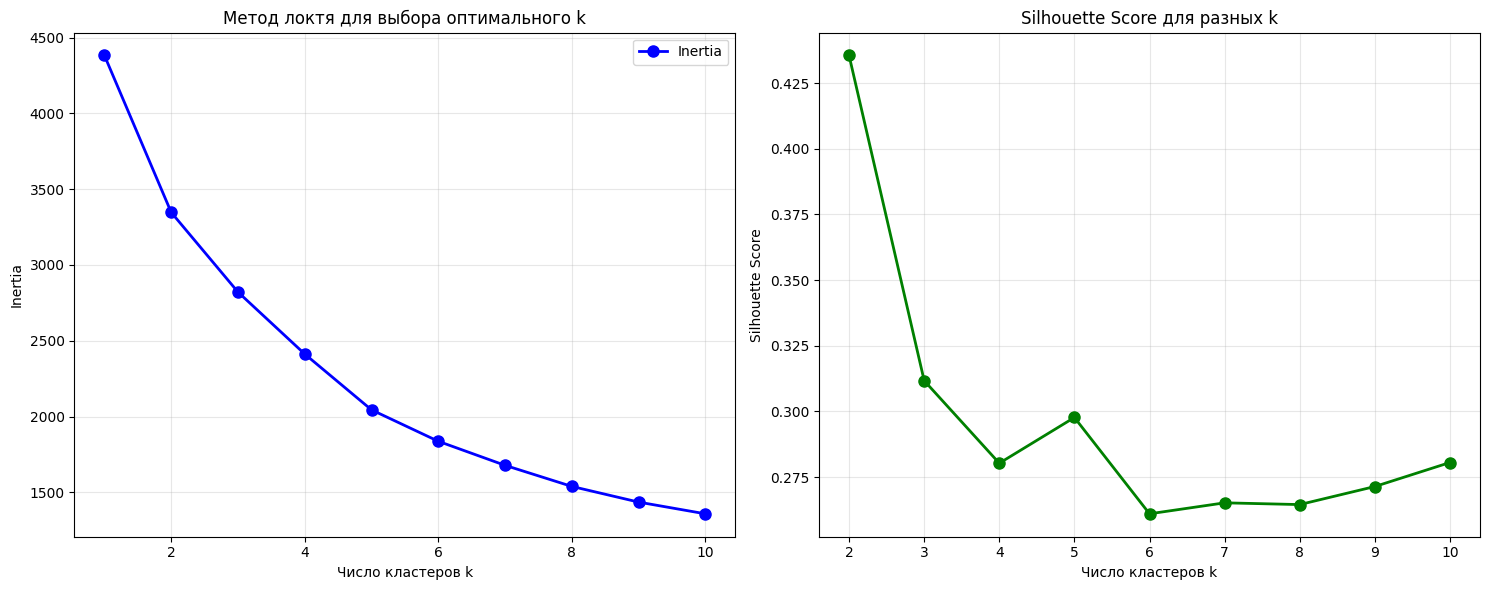

In [ ]:
# 2. Визуализация метода локтя

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Метод локтя (inertia)
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8, label='Inertia')
ax1.set_xlabel('Число кластеров k')
ax1.set_ylabel('Inertia')
ax1.set_title('Метод локтя для выбора оптимального k')
ax1.grid(True, alpha=0.3)
ax1.legend()

# График 2: Silhouette Score
ax2.plot(k_range[1:], silhouette_scores[1:], 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('Число кластеров k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score для разных k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Метод локтя не показал четкого излома, однако анализ Silhouette Score выявил, что оптимальное число кластеров k=2 (Silhouette=0.436). k=2 дает наилучший баланс между компактностью кластеров и их разделимостью. Это лучше, чем наше первоначальное предположение k=3 (Silhouette=0.312). Вероятно, в данных существуют две основные естественные группы пассажиров, а не три.



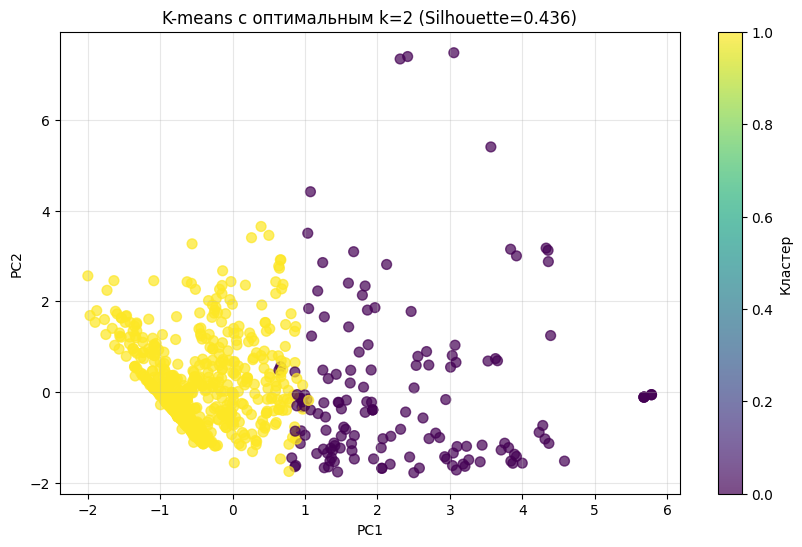

In [ ]:
# 3. Визуализация кластеров с оптимальным k=2

optimal_k_silhouette = 2
max_silhouette = silhouette_scores[1]

# Выполняем K-means с оптимальным k
kmeans_optimal = KMeans(n_clusters=optimal_k_silhouette, random_state=42, n_init=10)
clusters_optimal = kmeans_optimal.fit_predict(X)

# Визуализация
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_optimal,
                     cmap='viridis', alpha=0.7, s=50)
plt.colorbar(scatter, label='Кластер')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-means с оптимальным k={optimal_k_silhouette} (Silhouette={max_silhouette:.3f})')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 4. Статистика при оптимальном k

# Временно записываем оптимальные кластеры для анализа
df_not_processed['cluster_optimal'] = clusters_optimal

cluster_sizes_optimal = pd.Series(clusters_optimal).value_counts().sort_index()
print(f"Размеры кластеров:")
for cluster, size in cluster_sizes_optimal.items():
    print(f"  Кластер {cluster}: {size} пассажиров ({size/len(clusters_optimal)*100:.1f}%)")

# Основные метрики
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

silhouette_optimal = silhouette_score(X, clusters_optimal)
davies_optimal = davies_bouldin_score(X, clusters_optimal)
calinski_optimal = calinski_harabasz_score(X, clusters_optimal)

print(f"\nМетрики качества при k={optimal_k_silhouette}:")
print(f"Silhouette Score: {silhouette_optimal:.3f}")
print(f"Davies-Bouldin Index: {davies_optimal:.3f}")
print(f"Calinski-Harabasz Index: {calinski_optimal:.3f}")

print("\nХарактеристики кластеров при k=2:")
for cluster in [0, 1]:
    cluster_data = df_not_processed[df_not_processed['cluster_optimal'] == cluster]
    print(f"Кластер {cluster}:")
    print(f"  Средний возраст: {cluster_data['Age'].mean():.1f} лет")
    print(f"  Мужчины: {(cluster_data['Sex'] == 'male').mean()*100:.1f}%")
    print(f"  Преобладающий класс: {cluster_data['Pclass'].mode()[0]}")

df_not_processed.drop('cluster_optimal', axis=1, inplace=True)

Размеры кластеров:
  Кластер 0: 151 пассажиров (16.9%)
  Кластер 1: 740 пассажиров (83.1%)

Метрики качества при k=2:
Silhouette Score: 0.436
Davies-Bouldin Index: 1.496
Calinski-Harabasz Index: 274.841

Характеристики кластеров при k=2:
Кластер 0:
  Средний возраст: 17.4 лет
  Мужчины: 41.1%
  Преобладающий класс: 3
Кластер 1:
  Средний возраст: 32.6 лет
  Мужчины: 69.6%
  Преобладающий класс: 3


Статистика говорит о том, что пассажиры Титаника естественным образом разделяются на две демографические группы. Первая группа - молодежь до 20 лет с более сбалансированным гендерным составом. Вторая - взрослые пассажиры около 33 лет с преобладанием мужчин.

#  DBSSCAN кластеризация

Размерность данных: 9. Выбираем min_samples = 18.
Будем искать расстояние до 17-го соседа для определения eps


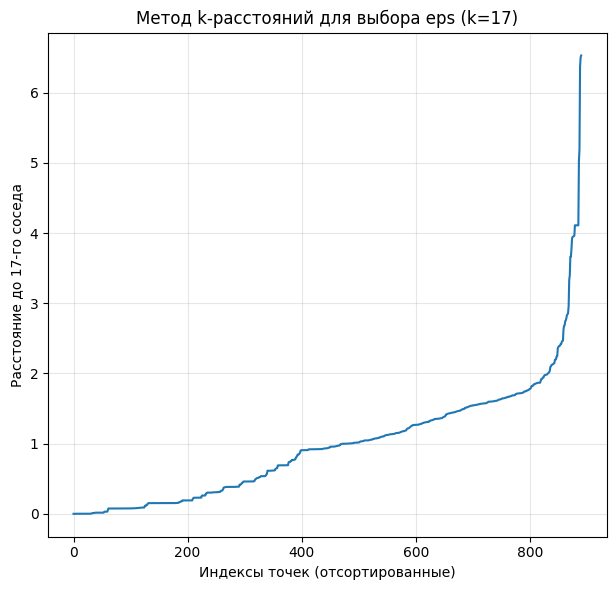

Оптимальное значение eps: 1.7


In [ ]:
# 1. Подбор параметров
dim = X.shape[1]
min_samples_val = 2 * dim  # Эмпирическое правило, для min_samples = 2 * размерность
k_neighbors = min_samples_val - 1

print(f"Размерность данных: {dim}. Выбираем min_samples = {min_samples_val}.")
print(f"Будем искать расстояние до {k_neighbors}-го соседа для определения eps")

# 2. Метод k-расстояний для определения eps
from sklearn.neighbors import NearestNeighbors

neigh = NearestNeighbors(n_neighbors=k_neighbors + 1)
neigh.fit(X)
distances, indices = neigh.kneighbors(X)
k_distance = np.sort(distances[:, k_neighbors], axis=0)

# Визуализация k-расстояния
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(k_distance)
plt.title(f'Метод k-расстояний для выбора eps (k={k_neighbors})')
plt.xlabel('Индексы точек (отсортированные)')
plt.ylabel(f'Расстояние до {k_neighbors}-го соседа')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Выбираем eps на основе анализа графика
optimal_eps = np.percentile(k_distance, 90)  # 90-й перцентиль
optimal_eps_cut = 1.7

print(f"Оптимальное значение eps: {optimal_eps_cut:.1f}")

Метод k-расстояний помогает определить оптимальный радиус eps. Для каждой точки мы смотрим, на каком расстоянии находится её k-й ближайший сосед - это показывает, насколько плотно расположены точки в разных областях данных. Точка локтя на графике это место, где начинается резкий рост расстояний. Это указывает на границу между плотными кластерами и шумом. Выбираем значение eps прямо перед этим резким ростом.

In [ ]:
# 3. Применяем DBSCAN с оптимальными параметрами
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=optimal_eps_cut, min_samples=min_samples_val)
dbscan_clusters = dbscan.fit_predict(X)

# Добавляем результаты в df_not_processed
df_not_processed['dbscan_cluster'] = dbscan_clusters

# Анализ результатов
unique_clusters = np.unique(dbscan_clusters)
n_clusters = len(unique_clusters) - (1 if -1 in unique_clusters else 0)
n_noise = np.sum(dbscan_clusters == -1)

print(f"Результаты")
print(f"Найдено кластеров: {n_clusters}")
print(f"Точек шума (outliers): {n_noise} ({n_noise/len(dbscan_clusters)*100:.1f}%)")
print(f"Распределение по кластерам:")
for cluster in unique_clusters:
    count = np.sum(dbscan_clusters == cluster)
    percentage = count/len(dbscan_clusters)*100
    if cluster == -1:
        print(f"  Шум (cluster -1): {count} точек ({percentage:.1f}%)")
    else:
        print(f"  Кластер {cluster}: {count} точек ({percentage:.1f}%)")

Результаты

Найдено кластеров: 2
Точек шума (outliers): 44 (4.9%)
Распределение по кластерам:
  Шум (cluster -1): 44 точек (4.9%)
  Кластер 0: 814 точек (91.4%)
  Кластер 1: 33 точек (3.7%)


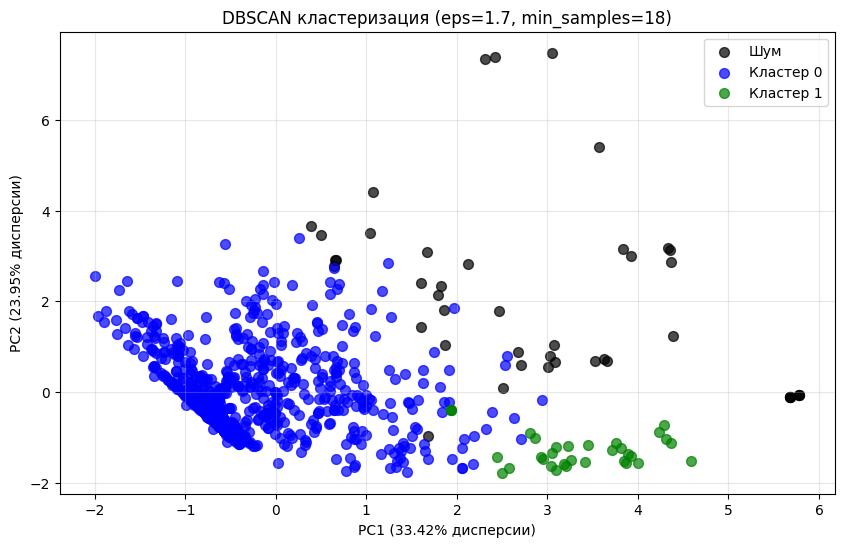

In [ ]:
# 4. Визуализация DBSCAN
plt.figure(figsize=(10, 6))

# Создаем цветовую схему
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, cluster in enumerate(sorted(df_not_processed['dbscan_cluster'].unique())):
    cluster_data = df_not_processed[df_not_processed['dbscan_cluster'] == cluster]
    cluster_indices = cluster_data.index

    # Находим соответствующие точки в PCA пространстве
    mask = [idx in cluster_indices for idx in range(len(X_pca))]
    xy = X_pca[mask]

    cluster_label = "Шум" if cluster == -1 else f"Кластер {cluster}"
    color = 'black' if cluster == -1 else colors[i % len(colors)]

    plt.scatter(xy[:, 0], xy[:, 1],
               c=color, label=cluster_label,
               alpha=0.7, s=50)

plt.title(f'DBSCAN кластеризация (eps={optimal_eps_cut:.1f}, min_samples={min_samples_val})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} дисперсии)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 5. Метрики качества DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("Метрики:")

# Убираем шум для расчета метрик (кластер -1)
mask_valid = dbscan_clusters != -1
X_valid = X[mask_valid]
labels_valid = dbscan_clusters[mask_valid]

if len(set(labels_valid)) > 1 and len(labels_valid) > 0:
    sil_dbscan = silhouette_score(X_valid, labels_valid)
    dbi_dbscan = davies_bouldin_score(X_valid, labels_valid)
    chi_dbscan = calinski_harabasz_score(X_valid, labels_valid)

    print(f"Silhouette Score: {sil_dbscan:.3f}")
    print(f"Davies-Bouldin Index: {dbi_dbscan:.3f}")
    print(f"Calinski-Harabasz Index: {chi_dbscan:.3f}")

    # Интерпретация метрик
    print(f"\nSilhouette: {'Хорошо' if sil_dbscan > 0.5 else 'Удовлетворительно' if sil_dbscan > 0.25 else 'Плохо'}")
    print(f"Davies-Bouldin: {'Хорошо' if dbi_dbscan < 1.0 else 'Удовлетворительно' if dbi_dbscan < 2.0 else 'Плохо'}")
    print(f"Calinski-Harabasz: {'Хорошо' if chi_dbscan > 300 else 'Удовлетворительно' if chi_dbscan > 200 else 'Плохо'}")
else:
    print("Недостаточно кластеров для расчета метрик (нужно хотя бы 2 кластера)")

Метрики:
Silhouette Score: 0.488
Davies-Bouldin Index: 0.700
Calinski-Harabasz Index: 175.667

Silhouette: Удовлетворительно
Davies-Bouldin: Хорошо
Calinski-Harabasz: Плохо


In [ ]:
# 6. Анализ характеристик кластеров DBSCAN
print("\nСтатистика")

for cluster in sorted(df_not_processed['dbscan_cluster'].unique()):
    cluster_data = df_not_processed[df_not_processed['dbscan_cluster'] == cluster]

    if cluster == -1:
        print(f"\nШум (Cluster -1, {len(cluster_data)} пассажиров)")
    else:
        print(f"\nКластер {cluster} ({len(cluster_data)} пассажиров) ")

    print(f"  Средний возраст: {cluster_data['Age'].mean():.1f} лет")
    print(f"  Средняя цена билета: {cluster_data['Fare'].mean():.1f}")
    print(f"  Мужчины: {(cluster_data['Sex'] == 'male').sum()} ({(cluster_data['Sex'] == 'male').mean()*100:.1f}%)")
    print(f"  Женщины: {(cluster_data['Sex'] == 'female').sum()} ({(cluster_data['Sex'] == 'female').mean()*100:.1f}%)")
    print(f"  Распределение по классам:")
    for pclass in sorted(cluster_data['Pclass'].unique()):
        count = (cluster_data['Pclass'] == pclass).sum()
        percentage = count/len(cluster_data)*100
        print(f"    {pclass} класс: {count} пассажиров ({percentage:.1f}%)")

    # Дополнительная статистика
    if cluster != -1:
        print(f"  Среднее число родственников: SibSp={cluster_data['SibSp'].mean():.1f}, Parch={cluster_data['Parch'].mean():.1f}")


Статистика

Шум (Cluster -1, 44 пассажиров)
  Средний возраст: 32.6 лет
  Средняя цена билета: 161.3
  Мужчины: 18 (40.9%)
  Женщины: 26 (59.1%)
  Распределение по классам:
    1 класс: 25 пассажиров (56.8%)
    2 класс: 2 пассажиров (4.5%)
    3 класс: 17 пассажиров (38.6%)

Кластер 0 (814 пассажиров) 
  Средний возраст: 30.6 лет
  Средняя цена билета: 25.2
  Мужчины: 540 (66.3%)
  Женщины: 274 (33.7%)
  Распределение по классам:
    1 класс: 191 пассажиров (23.5%)
    2 класс: 182 пассажиров (22.4%)
    3 класс: 441 пассажиров (54.2%)
  Среднее число родственников: SibSp=0.3, Parch=0.2

Кластер 1 (33 пассажиров) 
  Средний возраст: 7.2 лет
  Средняя цена билета: 32.1
  Мужчины: 19 (57.6%)
  Женщины: 14 (42.4%)
  Распределение по классам:
    3 класс: 33 пассажиров (100.0%)
  Среднее число родственников: SibSp=3.8, Parch=1.5


91% пассажиров образуют однородную массу (Кластер 0) - это взрослые люди со средним доходом всех классов

Выделилась только одна четкая группа (Кластер 1) - дети из 3-го класса

Богатые пассажиры помечены как шум - потому что они статистически нетипичны

**ГЛАВНЫЙ** **ВЫВОД**

DBSCAN:

Метрики: DBSCAN показал лучшие метрики качества (Silhouette 0.488 и DBI 0.700), что указывает на то, что найденные им кластеры гораздо более компактны и лучше разделены, чем кластеры K-Means.

Обнаружение Аномалий: DBSCAN автоматически выделил богатых пассажиров как шум, а детей 3-го класса — как отдельный, очень плотный кластер.

K-Means:

K-Means разделил весь датасет на две интерпретируемые, но менее плотные группы (мужчины против молодежи), не смог выявить "аномалии", смешивая их с основными кластерами.

Итог: для датасета с сильно различающейся плотностью и присутствием значительных выбросов, DBSCAN предоставил более качественное (по метрикам) и более осмысленное (по выделению аномалий) разделение, чем K-Means.